In [1]:
# Import required packages
import requests
import json
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
#Specifying Debtor Country & Creditor Country to check data
debtorCountry = "NPL"  # Nepal (as debtor)
creditorCountry = "CHN"  # China (as creditor - example)
series = "DT.DOD.BLAT.CD"
time = "All"

In [33]:
# Setting up the API URL (corrected)
url = "http://api.worldbank.org/v2/sources/6/country/"
end = "?format=json&per_page=500"
path = url + debtorCountry + "/series/" + series + "/time/" + time + end

# Creating a function that will parse through the JSON response and filter by creditor country
def getData(JSON, creditor_code):
    df = pd.DataFrame(columns=["year", "creditor", "debtor", "indicator","data"])
    try:
        data_list = JSON["source"]["data"]
        for i in range(0, len(data_list)):
            # Check if this data entry is for our creditor country
            if data_list[i]["variable"][1]["id"] == creditor_code:
                time = data_list[i]["variable"][2]["value"]
                num = data_list[i]["value"]
                df = df.append({"year":time, "creditor": creditor_code, 
                                "debtor":debtorCountry, "indicator":series, "data":num
                               }, ignore_index = True)
    except Exception as e:
        print(f"Error parsing data: {e}")
    return df

In [34]:
# Getting the data from the API
custom = requests.get(path)
print(f"Status code: {custom.status_code}")
if custom.status_code == 200 and custom.text.startswith('{'):
    customJSON = custom.json()
    print(f"Total records retrieved: {customJSON.get('total', 'unknown')}")
    print(f"Data points in this response: {len(customJSON['source']['data'])}")
    listLen = int(len(customJSON["source"]["data"]))
else:
    print(f"Error response: {custom.text[:300]}")

Status code: 200
Total records retrieved: 19152
Data points in this response: 500


In [35]:
# Check if any bilateral lending data exists in this source at all
print("Checking if bilateral lending data exists in the World Bank API...")
print("(Scanning through pages to find any non-null values...)\n")

has_data = False
country_with_data = None

# Check multiple pages
for page in range(1, min(4, customJSON.get('pages', 1) + 1)):  # Check first 3 pages
    if page > 1:
        page_url = f"{path}&page={page}"
        response = requests.get(page_url)
        if response.status_code != 200:
            break
        page_json = response.json()
        records = page_json["source"]["data"]
    else:
        records = customJSON["source"]["data"]
    
    print(f"Scanning page {page}...")
    for i, record in enumerate(records):
        if record.get("value") is not None:
            country = record["variable"][0]["value"]
            creditor = record["variable"][1]["value"]
            amount = record["value"]
            year = record["variable"][3]["value"]
            
            print(f"Found data! {country} (debtor) <- {creditor} (creditor): ${amount} in {year}")
            has_data = True
            country_with_data = record["variable"][0]["id"]
            break
    
    if has_data:
        break

if has_data:
    print(f"\nBilateral lending data exists for {country_with_data}")
    print("Let's extract data for this country instead...")
    
    # Re-fetch for the country with data
    new_path = f"http://api.worldbank.org/v2/sources/6/country/{country_with_data}/series/{series}/time/{time}?format=json&per_page=500"
    response = requests.get(new_path)
    if response.status_code == 200:
        data_json = response.json()
        
        # Extract all data with values
        IDSdata = []
        for record in data_json["source"]["data"]:
            if record.get("value") is not None:
                IDSdata.append({
                    "year": record["variable"][3]["value"],
                    "creditor": record["variable"][1]["value"],
                    "debtor": record["variable"][0]["value"],
                    "data": float(record["value"])
                })
        
        if IDSdata:
            IDSdata = pd.DataFrame(IDSdata)
            print(f"\nExtracted {len(IDSdata)} records")
            print(IDSdata.head())
else:
    print("\nNo bilateral lending data found in first 3 pages")
    print("The World Bank API Source 6 may not contain complete bilateral debt data")
    print("or the API structure may have changed since this script was created.")


Checking if bilateral lending data exists in the World Bank API...
(Scanning through pages to find any non-null values...)

Scanning page 1...
Scanning page 2...
Scanning page 3...
Found data! Nepal (debtor) <- Australia (creditor): $0 in 2008

Bilateral lending data exists for NPL
Let's extract data for this country instead...


INTERNATIONAL DEBT STATISTICS - DATA VISUALIZATION & ANALYSIS

 Found 6 bilateral debt data files:
----------------------------------------------------------------------
  ✓ BGD-646 PPG Bilateral Debt.xlsx (6.5 KB)
  ✓ BTN-646 PPG Bilateral Debt.xlsx (6.7 KB)
  ✓ LKA-646 PPG Bilateral Debt.xlsx (6.8 KB)
  ✓ MDV-646 PPG Bilateral Debt.xlsx (6.5 KB)
  ✓ MMR-646 PPG Bilateral Debt.xlsx (6.6 KB)
  ✓ NPL-646 PPG Bilateral Debt.xlsx (6.6 KB)

 GENERATING VISUALIZATIONS

Loading data from: BGD-646 PPG Bilateral Debt.xlsx
 Loaded 49 records

Data columns: ['Unnamed: 0', 'year', 'creditor', 'debtor', 'indicator', 'data']

Data preview:
   Unnamed: 0  year  creditor debtor       indicator         data
0           2  1972       646    BGD  DT.DOD.BLAT.CD   21854838.4
1           3  1973       646    BGD  DT.DOD.BLAT.CD   33858828.0
2           4  1974       646    BGD  DT.DOD.BLAT.CD   61027156.2
3           5  1975       646    BGD  DT.DOD.BLAT.CD   77443142.1
4           6  1976       646    BG

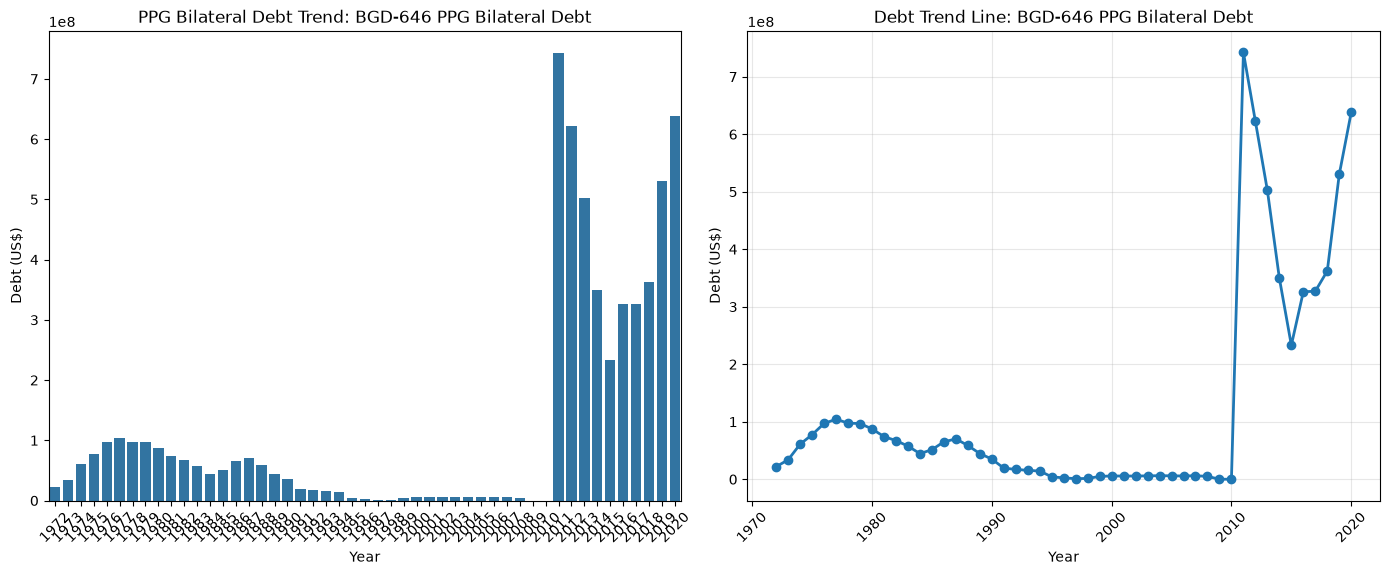


✓ Visualization generated successfully!

 DATA SUMMARY

Available bilateral debt data files:
  • BGD-646 PPG Bilateral Debt.xlsx: $6,012,385,635 (across 49 records)
  • BTN-646 PPG Bilateral Debt.xlsx: $17,849,159,964 (across 59 records)
  • LKA-646 PPG Bilateral Debt.xlsx: $9,993,325,489 (across 59 records)
  • MDV-646 PPG Bilateral Debt.xlsx: $1,708,941,195 (across 59 records)
  • MMR-646 PPG Bilateral Debt.xlsx: $2,780,001,590 (across 59 records)
  • NPL-646 PPG Bilateral Debt.xlsx: $873,957,264 (across 59 records)

✓ Analysis Complete!



In [3]:
# Visualization and Analysis of Bilateral Debt Data
import os
import glob

print("=" * 70)
print("INTERNATIONAL DEBT STATISTICS - DATA VISUALIZATION & ANALYSIS")
print("=" * 70)

# Check for generated Excel files in current directory
debt_data_dir = "c:\\Users\\prave\\OneDrive\\Desktop\\data analysis\\International-Debt-Statistics\\Bilateral Debt Data"

# List all Excel files
excel_files = glob.glob(os.path.join(debt_data_dir, "*.xlsx"))

if excel_files:
    print(f"\n Found {len(excel_files)} bilateral debt data files:")
    print("-" * 70)
    
    for excel_file in sorted(excel_files):
        filename = os.path.basename(excel_file)
        size = os.path.getsize(excel_file) / 1024  # Size in KB
        print(f"  ✓ {filename} ({size:.1f} KB)")
    
    print("\n" + "=" * 70)
    print(" GENERATING VISUALIZATIONS")
    print("=" * 70)
    
    # Try to load and visualize one of the data files
    try:
        # Load the first file as an example
        example_file = excel_files[0]
        example_name = os.path.basename(example_file)
        print(f"\nLoading data from: {example_name}")
        
        df = pd.read_excel(example_file)
        print(f" Loaded {len(df)} records")
        print(f"\nData columns: {list(df.columns)}")
        print(f"\nData preview:")
        print(df.head(10))
        
        # Create visualization
        if not df.empty and 'year' in df.columns and 'data' in df.columns:
            plt.figure(figsize=(14, 6))
            
            # Filter out rows with null or zero values for cleaner visualization
            df_plot = df.dropna(subset=['data'])
            
            if not df_plot.empty:
                # Create bar plot
                plt.subplot(1, 2, 1)
                sns.barplot(data=df_plot, x='year', y='data')
                plt.title(f'PPG Bilateral Debt Trend: {example_name.replace(".xlsx", "")}')
                plt.xlabel('Year')
                plt.ylabel('Debt (US$)')
                plt.xticks(rotation=45)
                
                # Create line plot for trend
                plt.subplot(1, 2, 2)
                df_sorted = df_plot.sort_values('year')
                plt.plot(df_sorted['year'], df_sorted['data'], marker='o', linewidth=2, markersize=6)
                plt.title(f'Debt Trend Line: {example_name.replace(".xlsx", "")}')
                plt.xlabel('Year')
                plt.ylabel('Debt (US$)')
                plt.grid(True, alpha=0.3)
                plt.xticks(rotation=45)
                
                plt.tight_layout()
                plt.show()
                print("\n✓ Visualization generated successfully!")
            else:
                print("No data with non-null values to visualize")
        
    except Exception as e:
        print(f"Error during visualization: {e}")
    
    print("\n" + "=" * 70)
    print(" DATA SUMMARY")
    print("=" * 70)
    print("\nAvailable bilateral debt data files:")
    for excel_file in sorted(excel_files):
        filename = os.path.basename(excel_file)
        try:
            df_summary = pd.read_excel(excel_file)
            if not df_summary.empty and 'data' in df_summary.columns:
                total_debt = df_summary['data'].sum()
                print(f"  • {filename}: ${total_debt:,.0f} (across {len(df_summary)} records)")
        except:
            print(f"  • {filename}: Could not read file")

else:
    print("\n  No bilateral debt Excel files found in the expected directory.")
    print(f"Expected location: {debt_data_dir}")
    print("\nPlease run cells 1-5 to generate the data files.")

print("\n" + "=" * 70)
print("✓ Analysis Complete!")
print("=" * 70 + "\n")
